<a href="https://colab.research.google.com/github/Sivanunna/Logicmojo-AI-ML-Sept25--siva-/blob/main/graduation_factors_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Filtering out the warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Admission_Predict.csv')
df

Mounted at /content/drive


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
395,396,324,110,3,3.5,3.5,9.04,1,0.82
396,397,325,107,3,3.0,3.5,9.11,1,0.84
397,398,330,116,4,5.0,4.5,9.45,1,0.91
398,399,312,103,3,3.5,4.0,8.78,0,0.67


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


In [ ]:
df.isnull().sum()

,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


In [ ]:
df.shape

(400, 9)

In [ ]:
df.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,200.500000,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.724350
std,115.614301,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.142609
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.340000
25%,100.750000,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.640000
50%,200.500000,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.730000
75%,300.250000,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,0.830000
max,400.000000,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,0.970000


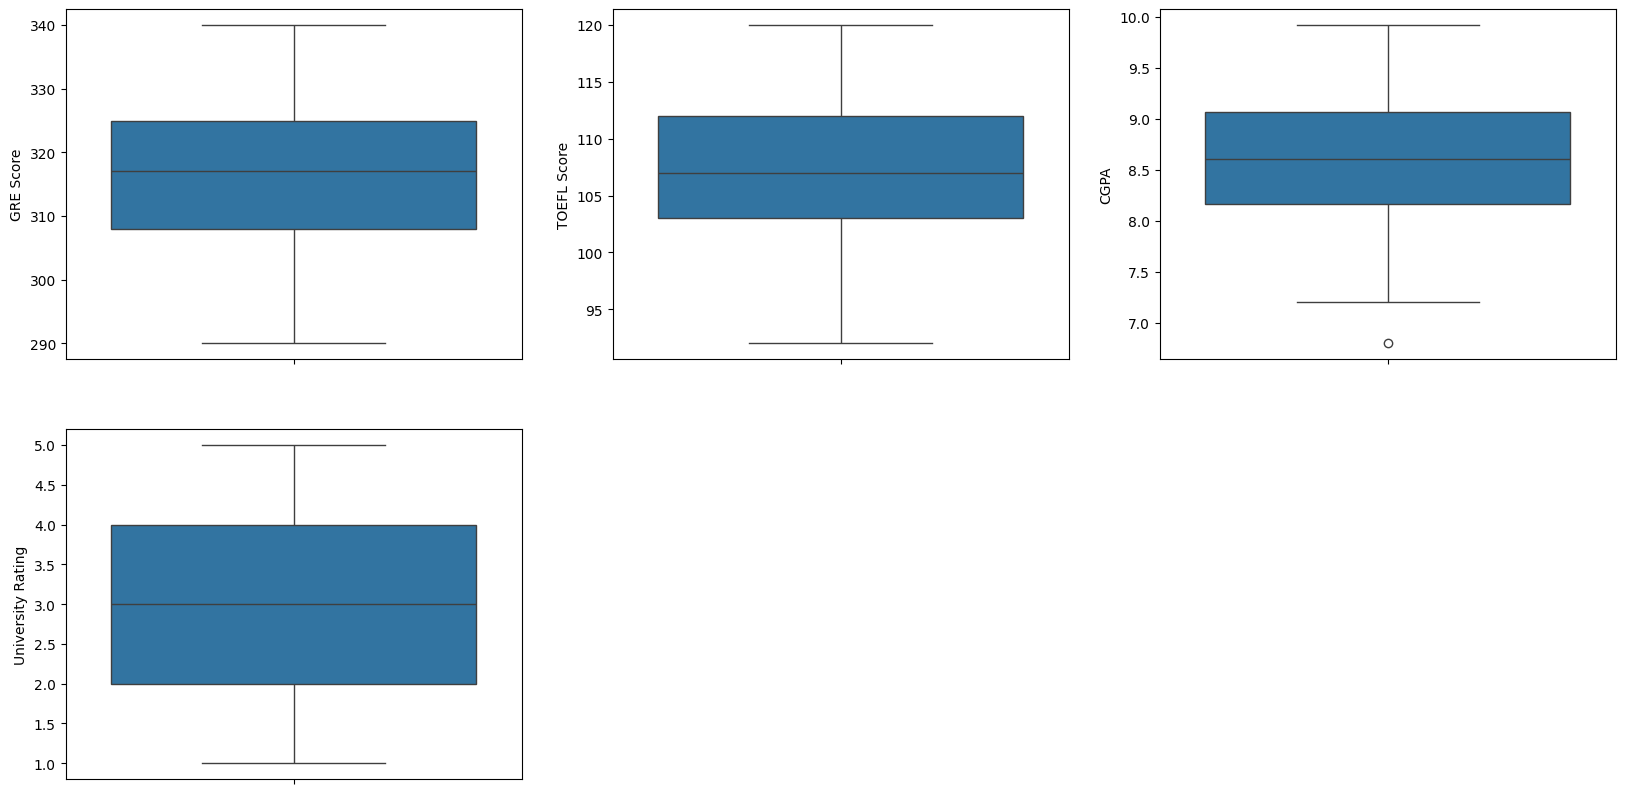

In [ ]:
plt.figure(figsize=(20,10))
plt.subplot(2,3,1)
sns.boxplot(df['GRE Score'])
plt.subplot(2,3,2)
sns.boxplot(df['TOEFL Score'])
plt.subplot(2,3,3)
sns.boxplot(df['CGPA'])
plt.subplot(2,3,4)
sns.boxplot(df['University Rating'])
plt.show()

In [ ]:
# most of the students gre score is around 317
# highest is 340 and lowest being 308
# most scores between 308 and 325
# we can interprate the same for the other factors

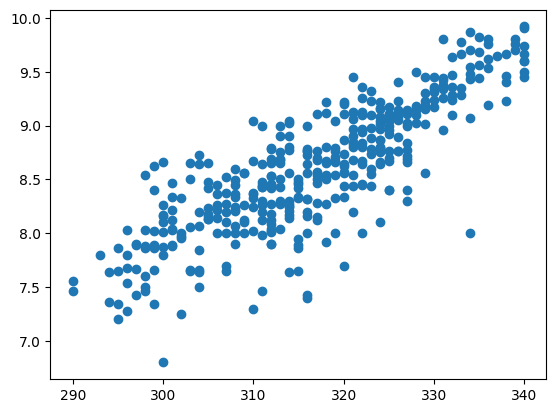

In [ ]:
plt.scatter(df['GRE Score'],df['CGPA'])

<Axes: >

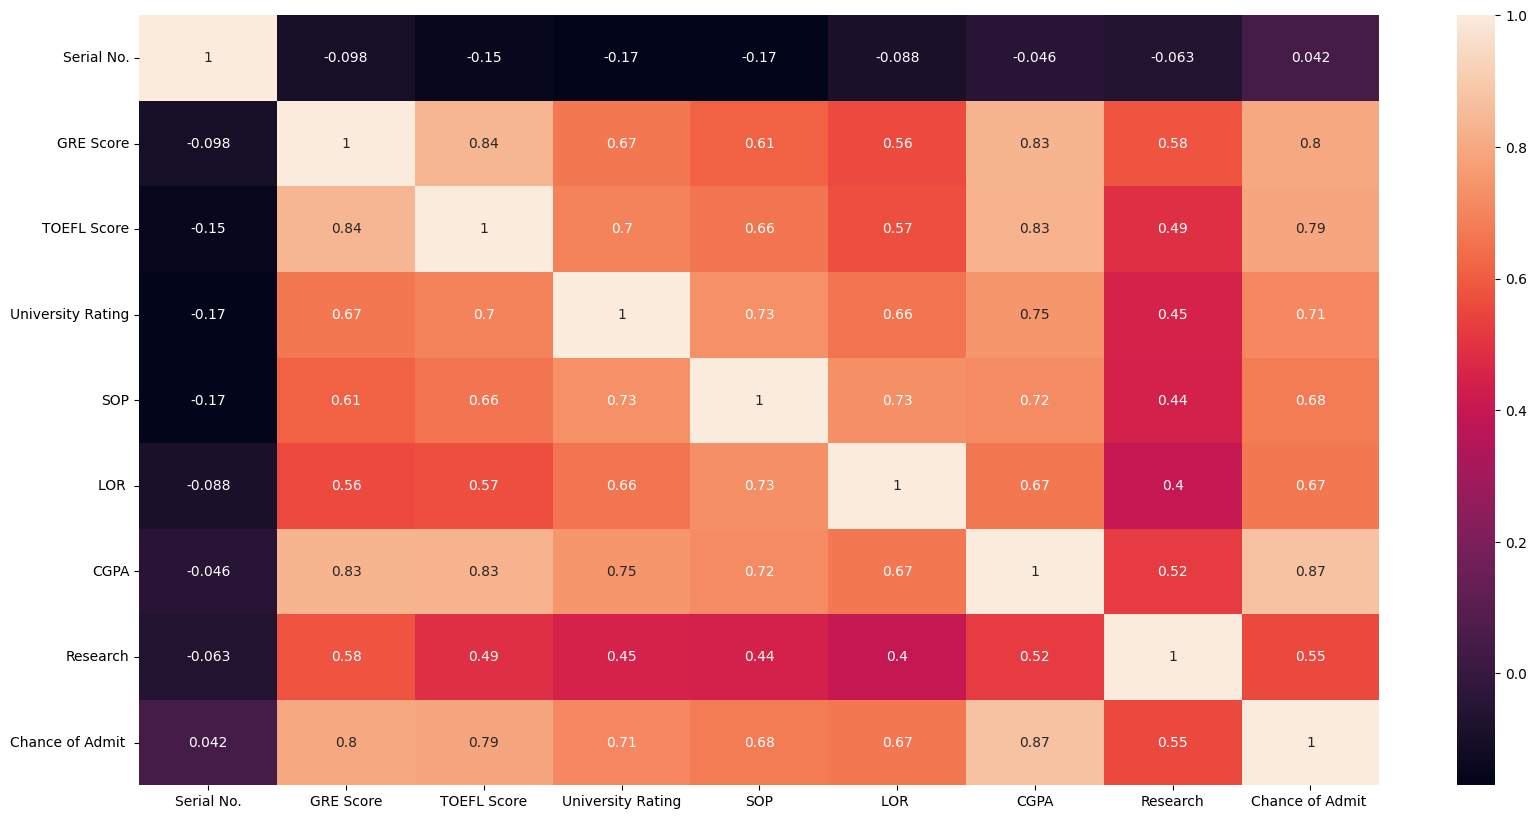

In [ ]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(),annot=True)

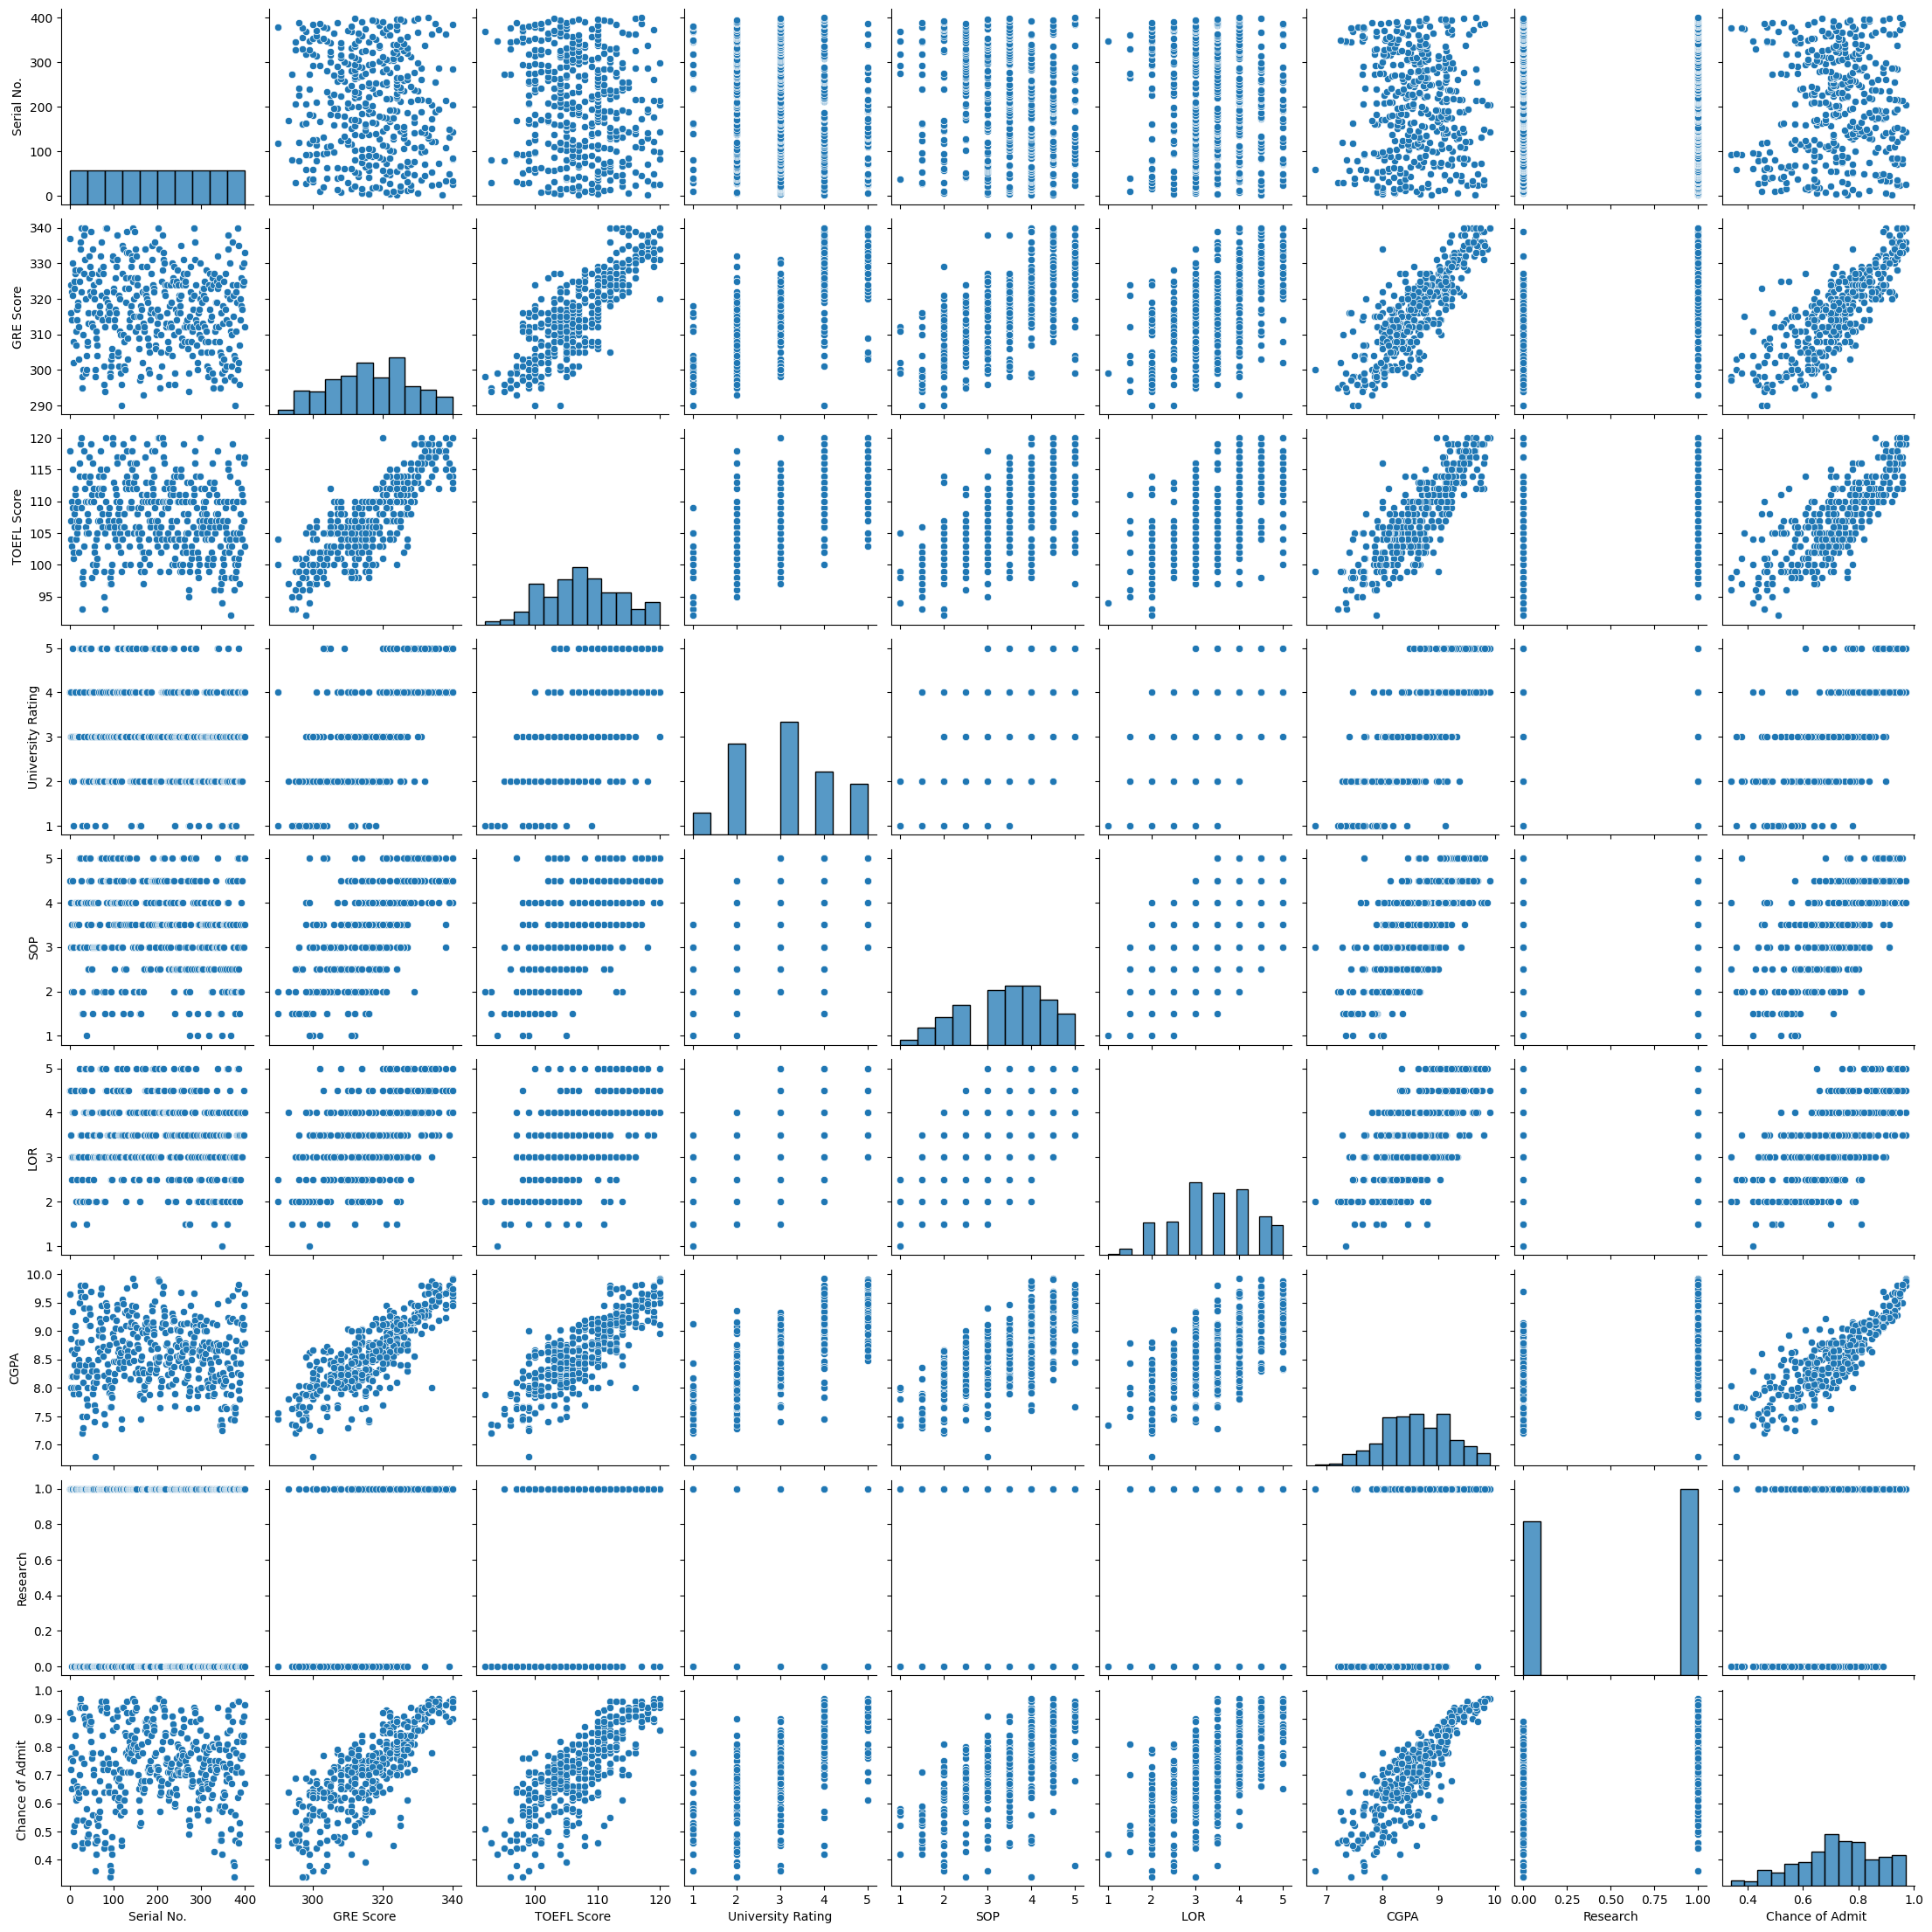

In [ ]:
sns.pairplot(df)

In [ ]:
df.drop(columns=['Serial No.'], inplace=True)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
df_train,df_test=train_test_split(df,train_size= 0.70, test_size=0.30, random_state=100)

In [ ]:
df_train.shape

(280, 8)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()

In [ ]:
df_train= pd.DataFrame(scaler.fit_transform(df_train),columns=df_train.columns,index=df_train.index)

In [ ]:
df_train.describe()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,280.000000,280.000000,280.000000,280.000000,280.000000,280.000000,280.000000,280.000000
mean,0.542571,0.558546,0.525000,0.609375,0.564796,0.586252,0.557143,0.614966
std,0.228987,0.216161,0.284454,0.253407,0.256065,0.191929,0.497613,0.230284
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.395000,0.392857,0.250000,0.375000,0.428571,0.448718,0.000000,0.476190
50%,0.540000,0.553571,0.500000,0.625000,0.571429,0.589744,1.000000,0.619048
75%,0.700000,0.714286,0.750000,0.750000,0.714286,0.730769,1.000000,0.781746
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: >

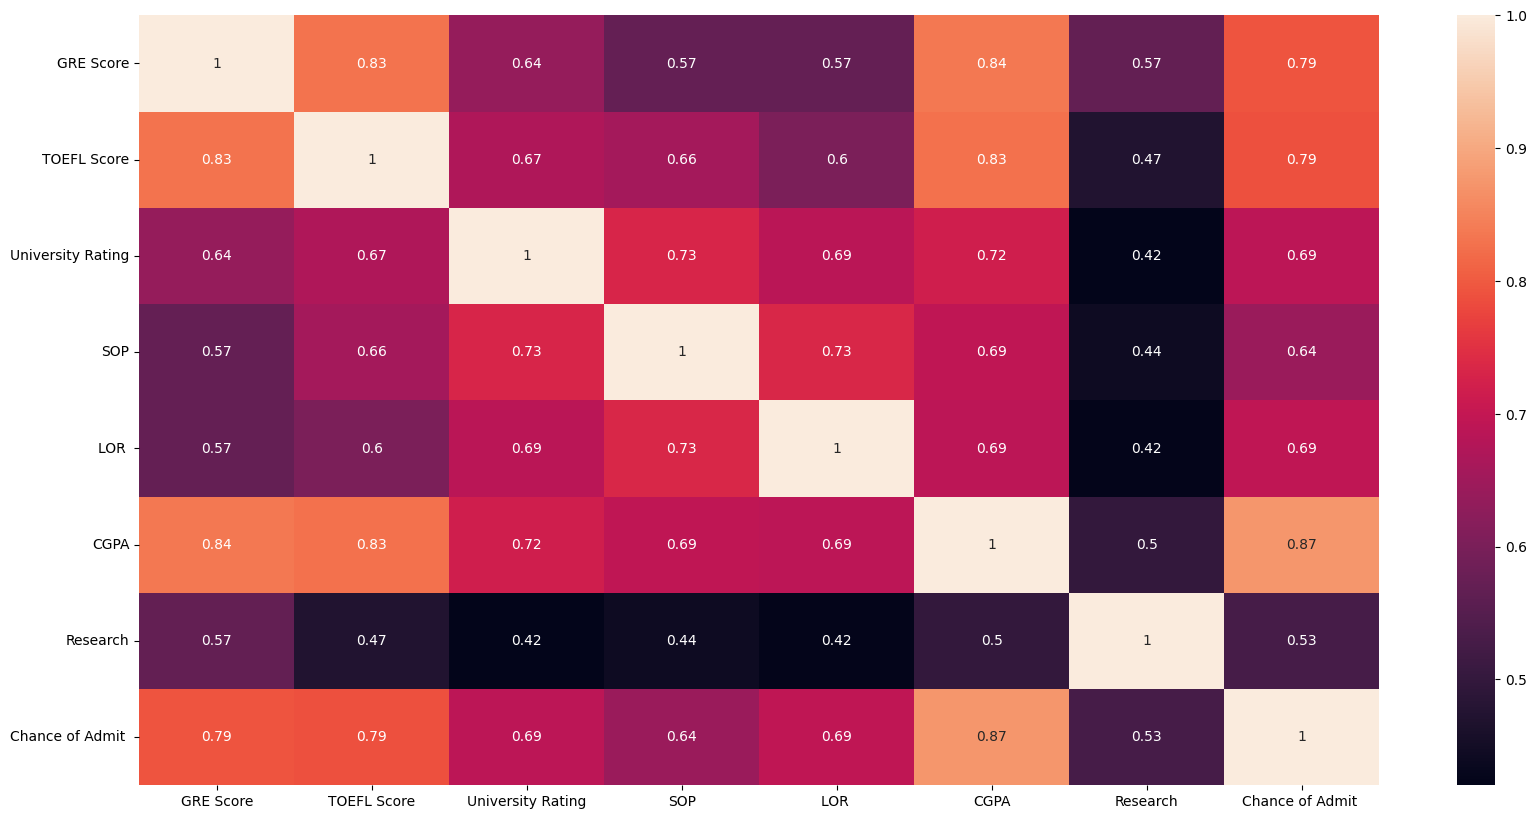

In [ ]:
plt.figure(figsize=(20,10))
sns.heatmap(df_train.corr(),annot=True)

In [ ]:
import statsmodels.api as sm

In [ ]:
y_train = df_train.pop('Chance of Admit ')
x_train = sm.add_constant(df_train)


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_train_const = sm.add_constant(x_train)
vif = pd.DataFrame()
vif['Feature'] = X_train_const.columns
vif['VIF'] = [
    variance_inflation_factor(X_train_const.values, i)
    for i in range(X_train_const.shape[1])
]

vif.sort_values(by='VIF', ascending=False)

,Feature,VIF
0,const,11.443176
6,CGPA,5.163243
1,GRE Score,4.698788
2,TOEFL Score,4.228600
4,SOP,3.040687
3,University Rating,2.799543
5,LOR,2.623487
7,Research,1.540123


In [ ]:
lr = sm.OLS(y_train, X_train_const).fit()
lr.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       Chance of Admit    R-squared:                       0.802
Model:                            OLS   Adj. R-squared:                  0.797
Method:                 Least Squares   F-statistic:                     157.3
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           9.40e-92
Time:                        10:14:58   Log-Likelihood:                 241.00
No. Observations:                 280   AIC:                            -466.0
Df Residuals:                     272   BIC:                            -436.9
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0148      0.021      0.705      0.481      -0.027       0.056
GRE Score             0.0960      0.059      1.632      0.104      -0.020       0.212
TOEFL Score           0.1513      0.059      2.559      0.011       0.035       0.268
University Rating     0.0433      0.037      1.186      0.237      -0.029       0.115
SOP                  -0.0640      0.043     -1.496      0.136      -0.148       0.020
LOR                   0.1513      0.039      3.849      0.000       0.074       0.229
CGPA                  0.6379      0.074      8.669      0.000       0.493       0.783
Research              0.0365      0.016      2.357      0.019       0.006       0.067
==============================================================================
Omnibus:                       64.772   Durbin-Watson:                   2.010
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              128.293
Skew:                          -1.183   Prob(JB):                     1.38e-28
Kurtosis:                       5.323   Cond. No.                         24.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
x_train.drop(columns=['University Rating'],inplace=True)

In [ ]:
X_train_const = sm.add_constant(x_train)
model = sm.OLS(y_train, X_train_const).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       Chance of Admit    R-squared:                       0.801
Model:                            OLS   Adj. R-squared:                  0.796
Method:                 Least Squares   F-statistic:                     183.0
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           1.34e-92
Time:                        10:14:58   Log-Likelihood:                 240.28
No. Observations:                 280   AIC:                            -466.6
Df Residuals:                     273   BIC:                            -441.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0092      0.020      0.449      0.654      -0.031       0.049
GRE Score       0.1015      0.059      1.728      0.085      -0.014       0.217
TOEFL Score     0.1567      0.059      2.656      0.008       0.041       0.273
SOP            -0.0473      0.040     -1.171      0.243      -0.127       0.032
LOR             0.1607      0.039      4.168      0.000       0.085       0.237
CGPA            0.6500      0.073      8.915      0.000       0.507       0.794
Research        0.0363      0.016      2.341      0.020       0.006       0.067
==============================================================================
Omnibus:                       62.762   Durbin-Watson:                   2.017
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              122.349
Skew:                          -1.155   Prob(JB):                     2.71e-27
Kurtosis:                       5.269   Cond. No.                         23.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
x_train.drop(columns=['SOP'],inplace=True)

In [ ]:
X_train_const = sm.add_constant(x_train)
model = sm.OLS(y_train, X_train_const).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       Chance of Admit    R-squared:                       0.800
Model:                            OLS   Adj. R-squared:                  0.796
Method:                 Least Squares   F-statistic:                     219.0
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           1.70e-93
Time:                        10:14:59   Log-Likelihood:                 239.58
No. Observations:                 280   AIC:                            -467.2
Df Residuals:                     274   BIC:                            -445.3
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0064      0.020      0.316      0.752      -0.034       0.046
GRE Score       0.1117      0.058      1.923      0.055      -0.003       0.226
TOEFL Score     0.1410      0.057      2.453      0.015       0.028       0.254
LOR             0.1394      0.034      4.098      0.000       0.072       0.206
CGPA            0.6338      0.072      8.848      0.000       0.493       0.775
Research        0.0339      0.015      2.205      0.028       0.004       0.064
==============================================================================
Omnibus:                       65.429   Durbin-Watson:                   2.008
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              130.577
Skew:                          -1.191   Prob(JB):                     4.42e-29
Kurtosis:                       5.349   Cond. No.                         21.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
y_train_pred = model.predict(X_train_const)

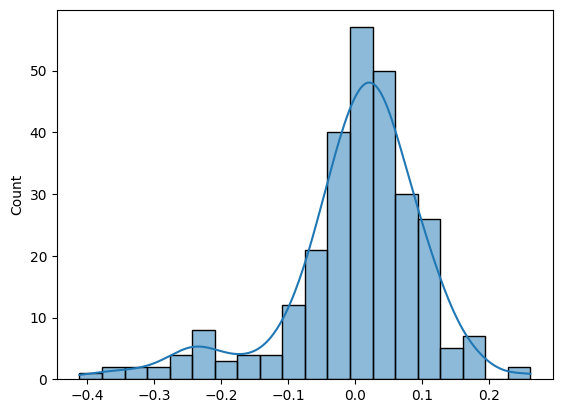

In [ ]:
sns.histplot(y_train - y_train_pred, bins=20, kde=True)
plt.show()

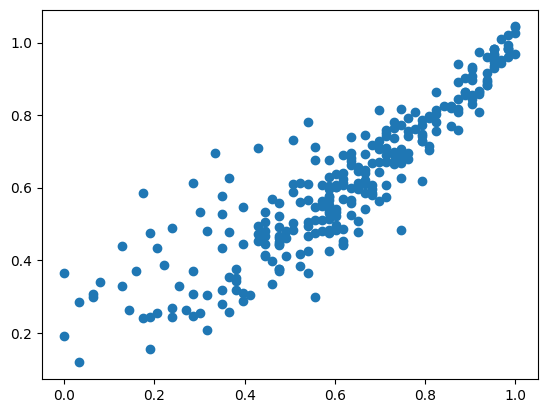

In [ ]:
plt.scatter(y_train, y_train_pred)

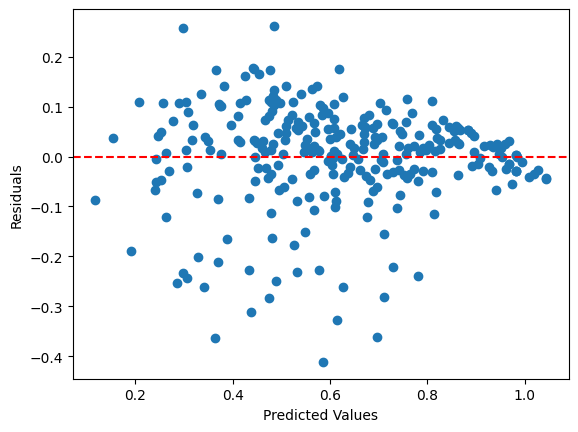

In [ ]:
plt.scatter(y_train_pred, y_train - y_train_pred)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

In [ ]:
df_test= pd.DataFrame(scaler.fit_transform(df_test),columns=df_test.columns,index=df_test.index)

In [ ]:
df_test

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
248,0.68,0.629630,0.50,0.625,0.750,0.647287,1.0,0.703704
318,0.68,0.666667,0.50,0.375,0.250,0.620155,1.0,0.685185
173,0.66,0.740741,0.75,0.750,0.875,0.786822,1.0,0.870370
285,0.82,0.851852,1.00,0.750,0.750,0.798450,1.0,0.944444
184,0.52,0.481481,0.25,0.375,0.750,0.434109,0.0,0.555556
...,...,...,...,...,...,...,...,...
80,0.44,0.444444,0.50,0.250,0.500,0.317829,1.0,0.148148
157,0.38,0.407407,0.25,0.250,0.375,0.410853,0.0,0.425926
300,0.38,0.481481,0.25,0.375,0.375,0.310078,0.0,0.370370
31,0.74,0.370370,0.50,0.750,0.750,0.426357,1.0,0.592593


In [ ]:
df_test.drop(columns=['University Rating'],inplace=True)

In [ ]:
df_test.drop(columns=['SOP'],inplace=True)

In [ ]:
df_test.describe()

,GRE Score,TOEFL Score,LOR,CGPA,Research,Chance of Admit
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,0.521167,0.513889,0.598958,0.514922,0.525000,0.550309
std,0.230867,0.225955,0.226231,0.227472,0.501468,0.253699
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.360000,0.370370,0.500000,0.354651,0.000000,0.402778
50%,0.540000,0.481481,0.625000,0.507752,1.000000,0.555556
75%,0.685000,0.666667,0.750000,0.698643,1.000000,0.740741
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
y_test = df_test.pop('Chance of Admit ')


In [ ]:
x_test = df_test


In [ ]:
x_test_sm = sm.add_constant ( x_test)

In [ ]:
x_test_sm

,const,GRE Score,TOEFL Score,LOR,CGPA,Research
248,1.0,0.68,0.629630,0.750,0.647287,1.0
318,1.0,0.68,0.666667,0.250,0.620155,1.0
173,1.0,0.66,0.740741,0.875,0.786822,1.0
285,1.0,0.82,0.851852,0.750,0.798450,1.0
184,1.0,0.52,0.481481,0.750,0.434109,0.0
...,...,...,...,...,...,...
80,1.0,0.44,0.444444,0.500,0.317829,1.0
157,1.0,0.38,0.407407,0.375,0.410853,0.0
300,1.0,0.38,0.481481,0.375,0.310078,0.0
31,1.0,0.74,0.370370,0.750,0.426357,1.0


In [ ]:
y_test_pred = model.predict(x_test_sm)

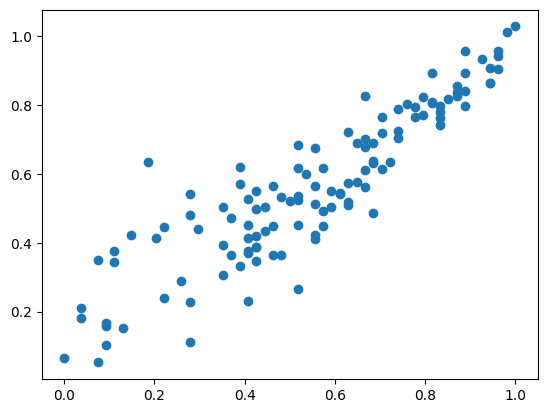

In [ ]:
plt.scatter(y_test, y_test_pred)

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error
np.sqrt(mean_squared_error(y_test, y_test_pred))

np.float64(0.11099539715956587)

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test, y_test_pred)

0.8069787770211452